# Laboratorio 3 - Clasificación
### Sergio David Ferreira - Juan David Gutierrez

## Librerias utilizadas

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Carga y Exploración de Datos
Se cargan los datos y se realiza una copia de seguridad para mantener la integridad de la fuente. Se utiliza `.describe()` para entender la distribución de las variables numéricas (como edad, BMI y pasos diarios).

In [2]:
fitness_data = pd.read_csv('data/Datos_Laboratorio3.csv', sep=';')

data = fitness_data.copy()
data.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


Observamos que existen valores que están mal normalizados en la columna `Objetivo`

In [3]:
data['Objetivo'].value_counts()

Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

Normalizamos pasando siempre a `Perdida grasa` para coincidir con los datos de prueba

In [4]:
data.loc[data['Objetivo'] == 'grasa', 'Objetivo'] = 'Perdida grasa'

Definimos dos variables objetivo (Target): `Plan_entrenamiento` y `Plan_nutricion`.

In [5]:
X = data.drop(columns=['Plan_entrenamiento', 'Plan_nutricion'])

y_entrenamiento = data['Plan_entrenamiento']
y_nutricion = data['Plan_nutricion']

X_train, X_test, y_entrenamiento_train, y_entrenamiento_test, y_nutricion_train, y_nutricion_test = train_test_split(
    X, 
    y_entrenamiento, 
    y_nutricion, 
    test_size=0.2, 
    random_state=42
)

Se realiza un diagnóstico de valores faltantes. Como se observa en el análisis de `isnull()`, la variable `Peso` presenta datos faltantes, los cuales serán tratados mediante imputación dentro del pipeline para no perder filas valiosas de información.

In [6]:
( (X.isnull().sum() / X.shape[0]) ).sort_values(ascending=False)

Peso                       0.001134
Edad                       0.000000
Genero                     0.000000
Altura                     0.000000
BMI                        0.000000
Objetivo                   0.000000
Condicion_salud            0.000000
Nivel_Actividad            0.000000
Nivel_experiencia          0.000000
Dieta_preferida            0.000000
Horas_sueño                0.000000
Entrenamiento_preferido    0.000000
Cantidad_equipo            0.000000
Tiempo_disponible          0.000000
Tiene_alergia              0.000000
Problemas_digestivos       0.000000
Fumador                    0.000000
Cigarrillos_dia            0.000000
Alcohol                    0.000000
Alcohol_semana             0.000000
Score_micronutrientes      0.000000
Ingesta_proteinas          0.000000
Pasos_dia                  0.000000
Ingesta_agua               0.000000
dtype: float64

Ahora se aplica una estrategia diferenciada por tipo de variable:

1. **Variables Nominales:** Aplicamos `OneHotEncoder` para representar categorías sin orden intrínseco.
2. **Variables Ordinales:** Se utiliza `OrdinalEncoder` para preservar la jerarquía lógica en niveles de actividad y experiencia (Bajo < Moderado < Alto).
3. **Variables Numéricas:** Se preparan para ser escaladas (`StandardScaler`) para que variables con rangos grandes no dominen injustificadamente sobre variables de rango pequeño.

In [7]:
categorical_cols = X.select_dtypes(include=['str']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
ordinal_cols = ['Nivel_Actividad', 'Nivel_experiencia']
binary_cols = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']

categorical_cols = list(categorical_cols.drop(ordinal_cols))
numerical_cols = list(numerical_cols.drop(binary_cols))
encoder = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('ordinal', OrdinalEncoder(categories=[['Bajo', 'Moderado', 'Alto'], ['Principiante', 'Intermedio', 'Avanzado']]), ordinal_cols)
])

## Análisis de Distribución de Variables
Antes de modelar generamos histogramas para las variables numéricas con el fin de identificar:
* **Sesgos:** Si los datos están muy cargados a la izquierda o derecha.
* **Outliers:** Puntos que se alejan demasiado de la media y podrían confundir al modelo.
* **Escalas:** Confirmar que variables como "Pasos" y "Horas de sueño" necesitan normalización.

array([[<Axes: title={'center': 'Edad'}>,
        <Axes: title={'center': 'Peso'}>,
        <Axes: title={'center': 'Altura'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Horas_sueño'}>,
        <Axes: title={'center': 'Cantidad_equipo'}>,
        <Axes: title={'center': 'Tiempo_disponible'}>,
        <Axes: title={'center': 'Cigarrillos_dia'}>],
       [<Axes: title={'center': 'Alcohol_semana'}>,
        <Axes: title={'center': 'Score_micronutrientes'}>,
        <Axes: title={'center': 'Ingesta_proteinas'}>,
        <Axes: title={'center': 'Pasos_dia'}>],
       [<Axes: title={'center': 'Ingesta_agua'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

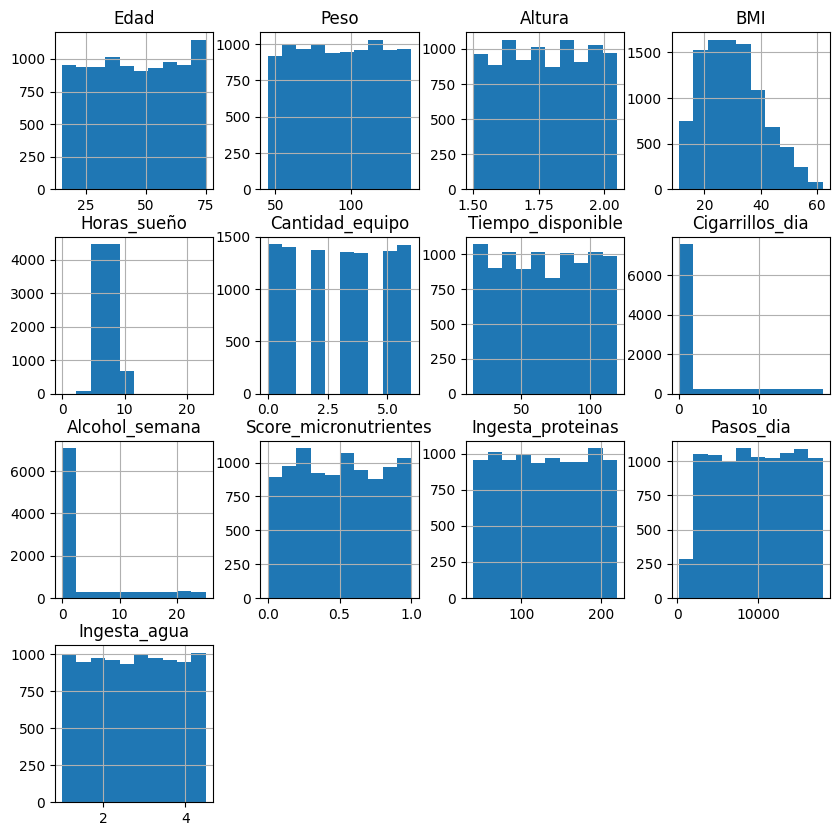

In [8]:
X[numerical_cols].hist(figsize=(10, 10))

En los datos detectamos valores en la variable `Horas_sueño` que podrían ser errores de entrada o casos extremos poco representativos. Utilizamos un `FunctionTransformer` para mantener los registros pero limitar sus valores a un rango biológicamente razonable.

In [9]:
def limiter(data):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=numerical_cols + binary_cols)

    data = data.copy()
    data['Horas_sueño'] = data['Horas_sueño'].clip(4, 15)

    return data

limiter_transformer = FunctionTransformer(limiter)

Calculamos el **VIF**. Si es superior a 5 o 10 sugiere que una variable es redundante.

In [10]:
X_vif = add_constant(X[numerical_cols].dropna())

vif = pd.DataFrame()
vif['Variable'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif[1:].sort_values('VIF', ascending=False))

                 Variable        VIF
4                     BMI  36.382162
2                    Peso  26.688595
3                  Altura  10.480731
10  Score_micronutrientes   1.002000
5             Horas_sueño   1.001908
7       Tiempo_disponible   1.001574
9          Alcohol_semana   1.001440
13           Ingesta_agua   1.001389
1                    Edad   1.001376
11      Ingesta_proteinas   1.001134
6         Cantidad_equipo   1.000672
8         Cigarrillos_dia   1.000604
12              Pasos_dia   1.000528


In [11]:
X_vif = add_constant(X[numerical_cols].dropna())
X_vif.drop(columns=['Peso'], inplace=True)

vif = pd.DataFrame()
vif['Variable'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif[1:].sort_values('VIF', ascending=False))

                 Variable       VIF
2                  Altura  1.366228
3                     BMI  1.364274
4             Horas_sueño  1.001908
9   Score_micronutrientes  1.001690
8          Alcohol_semana  1.001280
1                    Edad  1.001178
6       Tiempo_disponible  1.001147
10      Ingesta_proteinas  1.001106
12           Ingesta_agua  1.001001
5         Cantidad_equipo  1.000672
7         Cigarrillos_dia  1.000568
11              Pasos_dia  1.000491


Decidimos eliminar `Peso` y otras variables redundantes (`Alcohol`, `Fumador`) para simplificar el modelo y reducir el ruido, manteniendo un VIF saludable en el resto de las columnas.

In [12]:
def dropper(data):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=numerical_cols + binary_cols)

    return data.drop(columns=['Alcohol', 'Fumador', 'Peso'], errors='ignore')

dropper_transformer = FunctionTransformer(dropper)

## Construcción del Pipeline
Finalmente, consolidamos todas las decisiones anteriores en un pipeline.

* **Imputación:** Usamos la **mediana** para rellenar valores faltantes, ya que es más robusta a los valores atípicos que el promedio.
* **Estandarización:** Aplicamos `StandardScaler` para que todas las variables tengan media 0 y desviación estándar 1.
* **Dropper:** Eliminamos las columnas identificadas en el análisis VIF para optimizar el rendimiento.
* **ColumnTransformer:** Esto nos permite aplicar el pipeline numérico a las columnas de medidas y el pipeline categórico a las de texto simultáneamente, dejando los datos listos para el entrenamiento.

In [13]:
numeric_transformer = Pipeline(steps=[
    ('limiter', limiter_transformer),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('dropper', dropper_transformer),
])

preprocessor = ColumnTransformer(transformers=[
    ('categorical', encoder, categorical_cols + ordinal_cols),
    ('numerical', numeric_transformer, numerical_cols + binary_cols),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

## Modelos de regresion logistica con busqueda de hiperparametros
Se entrenan dos modelos (entrenamiento y nutricion) usando el mismo preprocesamiento dentro de un `Pipeline` y `GridSearchCV` con validacion cruzada.


In [14]:
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.linear_model._logistic')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nota: no se usa 'liblinear' porque en esta version no soporta multiclase (3 o mas clases).
param_grid_lr = [
    {
        'classifier__solver': ['lbfgs', 'newton-cg', 'saga'],
        'classifier__penalty': ['l2'],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced'],
    },
    {
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0.1, 0.5, 0.9],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced'],
    },
]

def run_logistic_gridsearch(target_name, y_train, y_test):
    pipeline_lr = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=2000, random_state=42)),
    ])

    grid = GridSearchCV(
        estimator=pipeline_lr,
        param_grid=param_grid_lr,
        scoring='f1_macro',
        cv=cv,
        n_jobs=1,
        refit=True,
        verbose=1,
        error_score='raise',
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

    print(f'\n{target_name}')
    print('-' * len(target_name))
    print('Mejores hiperparametros:', grid.best_params_)
    print('Mejor F1-macro (CV):', round(grid.best_score_, 4))
    print('Accuracy (test):', round(accuracy_score(y_test, y_pred), 4))
    print('F1-weighted (test):', round(f1_score(y_test, y_pred, average='weighted'), 4))
    print('F1-macro (test):', round(f1_score(y_test, y_pred, average='macro'), 4))
    print('\nReporte de clasificacion:\n')
    print(classification_report(y_test, y_pred))

    cv_summary = (
        pd.DataFrame(grid.cv_results_)[['mean_test_score', 'std_test_score', 'params']]
        .sort_values('mean_test_score', ascending=False)
        .head(10)
    )
    print('Top 10 combinaciones por F1-macro en CV:')
    print(cv_summary.to_string(index=False))

    return grid


In [15]:
warnings.filterwarnings('ignore', module='sklearn.linear_model._sag')
grid_entrenamiento = run_logistic_gridsearch(
    target_name='Modelo para recomendacion de plan de entrenamiento',
    y_train=y_entrenamiento_train,
    y_test=y_entrenamiento_test,
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Modelo para recomendacion de plan de entrenamiento
--------------------------------------------------
Mejores hiperparametros: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.9, 'classifier__solver': 'saga'}
Mejor F1-macro (CV): 0.6635
Accuracy (test): 0.668
F1-weighted (test): 0.6448
F1-macro (test): 0.6566

Reporte de clasificacion:

              precision    recall  f1-score   support

        Alto       0.91      0.75      0.82       137
        Bajo       0.45      0.25      0.32       479
       Medio       0.66      0.78      0.72       599
     Ninguno       0.71      0.84      0.77       725

    accuracy                           0.67      1940
   macro avg       0.68      0.65      0.66      1940
weighted avg       0.64      0.67      0.64      1940

Top 10 combinaciones por F1-macro en CV:
 mean_test_score  std_test_score                                                        

In [16]:
grid_nutricion = run_logistic_gridsearch(
    target_name='Modelo para recomendacion de plan de nutricion',
    y_train=y_nutricion_train,
    y_test=y_nutricion_test,
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Modelo para recomendacion de plan de nutricion
----------------------------------------------
Mejores hiperparametros: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.9, 'classifier__solver': 'saga'}
Mejor F1-macro (CV): 0.7329
Accuracy (test): 0.7809
F1-weighted (test): 0.7753
F1-macro (test): 0.7148

Reporte de clasificacion:

               precision    recall  f1-score   support

   Balanceado       0.81      0.88      0.84       819
       Basico       0.67      0.60      0.63       465
Especializado       0.65      0.45      0.53       125
     Sin plan       0.84      0.86      0.85       531

     accuracy                           0.78      1940
    macro avg       0.74      0.70      0.71      1940
 weighted avg       0.77      0.78      0.78      1940

Top 10 combinaciones por F1-macro en CV:
 mean_test_score  std_test_score                                                        

## Modelos basados en árboles de decisión con búsqueda de hiperparámetros
Se entrenan dos modelos (entrenamiento y nutricion) usando el mismo preprocesamiento dentro de un `Pipeline` y `GridSearchCV` con validacion cruzada.


In [17]:
param_grid_dt = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [20, 50],
    'classifier__min_samples_leaf': [10, 20],
    'classifier__class_weight': [None, 'balanced']
}

def run_tree_gridsearch(target_name, y_train, y_test):
    pipeline_dt = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])

    grid = GridSearchCV(
        estimator=pipeline_dt,
        param_grid=param_grid_dt,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    grid.fit(X_train, y_train)
    
    # Evaluación
    y_pred = grid.predict(X_test)
    print(f'\nRESULTADOS PARA: {target_name}')
    print('Best Params:', grid.best_params_)
    print('F1-Macro (Test):', round(f1_score(y_test, y_pred, average='macro'), 4))
    print('\nReporte de Clasificación:\n', classification_report(y_test, y_pred))
    
    return grid

Se ejecuta primero el modelo para el plan de entrenamiento:

In [18]:
# Ejecución para Entrenamiento
grid_tree_entrenamiento = run_tree_gridsearch(
    "Plan de Entrenamiento (Árbol)", y_entrenamiento_train, y_entrenamiento_test
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits

RESULTADOS PARA: Plan de Entrenamiento (Árbol)
Best Params: {'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 20}
F1-Macro (Test): 1.0

Reporte de Clasificación:
               precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       137
        Bajo       1.00      1.00      1.00       479
       Medio       1.00      1.00      1.00       599
     Ninguno       1.00      1.00      1.00       725

    accuracy                           1.00      1940
   macro avg       1.00      1.00      1.00      1940
weighted avg       1.00      1.00      1.00      1940



Se ejecuta ahora el modelo para el plan de nutrición:

In [19]:
# Ejecución para Nutrición
grid_tree_nutricion = run_tree_gridsearch(
    "Plan de Nutrición (Árbol)", y_nutricion_train, y_nutricion_test
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits

RESULTADOS PARA: Plan de Nutrición (Árbol)
Best Params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 20}
F1-Macro (Test): 0.9976

Reporte de Clasificación:
                precision    recall  f1-score   support

   Balanceado       1.00      1.00      1.00       819
       Basico       1.00      0.99      0.99       465
Especializado       1.00      1.00      1.00       125
     Sin plan       1.00      1.00      1.00       531

     accuracy                           1.00      1940
    macro avg       1.00      1.00      1.00      1940
 weighted avg       1.00      1.00      1.00      1940



## Análisis de importancia de características
Para el mejor clasificador de ambos modelos evaluamos la importancia de las características en las decisiones del clasificador, para el clasificador basado en árbol de decisión se evalúa usando `feature_importances_` mientras que para la regresión logística se usa directamente los coeficientes `coef_`

Top 10 Decision Tree:
onehot__Objetivo_Ganancia muscular    0.246396
ordinal__Nivel_experiencia            0.218287
ordinal__Nivel_Actividad              0.195369
Tiempo_disponible                     0.193846
BMI                                   0.146102
onehot__Genero_Femenino               0.000000
onehot__Genero_Masculino              0.000000
onehot__Genero_Otro                   0.000000
onehot__Objetivo_General              0.000000
onehot__Condicion_salud_Diabetes      0.000000
dtype: float64

Top 10 Logistic Regression (coef abs mean):
ordinal__Nivel_Actividad                        0.283683
ordinal__Nivel_experiencia                      0.270697
onehot__Objetivo_Ganancia muscular              0.228666
Tiempo_disponible                               0.094157
BMI                                             0.091941
Edad                                            0.003602
onehot__Dieta_preferida_No-Vegetariano          0.002428
Score_micronutrientes                           0

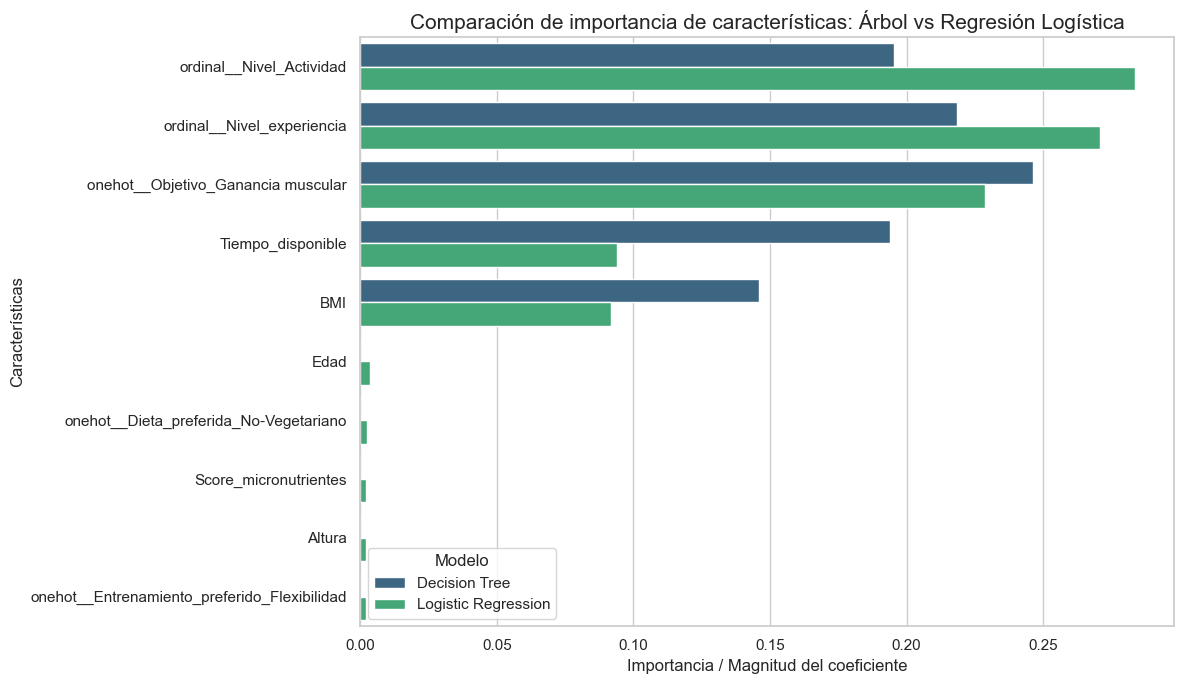

In [20]:

cat_names = list(grid_entrenamiento.best_estimator_['preprocessor']
                 .transformers_[0][1].get_feature_names_out())
num_cols_final = [c for c in (numerical_cols + binary_cols) if c not in ['Alcohol', 'Fumador', 'Peso']]
all_feature_names = cat_names + num_cols_final

importances_dt = grid_tree_entrenamiento.best_estimator_['classifier'].feature_importances_
coefs_lr = grid_entrenamiento.best_estimator_['classifier'].coef_

if coefs_lr.ndim == 1:
    log_importance = pd.Series(np.abs(coefs_lr), index=all_feature_names)
else:
    log_importance = pd.Series(np.abs(coefs_lr).mean(axis=0), index=all_feature_names)

importancia_entrenamiento = pd.Series(importances_dt, index=all_feature_names).sort_values(ascending=False)
importancia_logistica = log_importance.sort_values(ascending=False)
importancia_logistica = importancia_logistica/importancia_logistica.sum()

print('Top 10 Decision Tree:')
print(importancia_entrenamiento.head(10))
print('\nTop 10 Logistic Regression (coef abs mean):')
print(importancia_logistica.head(10))

top_features = pd.DataFrame({
    'Decision Tree': importancia_entrenamiento,
    'Logistic Regression': importancia_logistica
}).fillna(0)
top_features = top_features.assign(Max=top_features.max(axis=1)).sort_values('Max', ascending=False).head(10).drop(columns='Max')
top_features = top_features.reset_index().melt(id_vars='index', var_name='Modelo', value_name='Importancia')

plt.figure(figsize=(12, 7))
sns.set_theme(style='whitegrid')
sns.barplot(data=top_features, x='Importancia', y='index', hue='Modelo', palette='viridis')

plt.title('Comparación de importancia de características: Árbol vs Regresión Logística', fontsize=15)
plt.xlabel('Importancia / Magnitud del coeficiente', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()


El análisis de las variables de mayor peso revela que el modelo de entrenamiento de árbol de decisión ignora por completo variables demográficas como el género (importancia 0.0) y se centra exclusivamente en el perfil de rendimiento, mientras que para el modelo de regresión logística existe un ligero peso para las variables demográficas, sin embargo mantiene las variables de mayor importancia las mismas a las halladas por el árbol de decisión, estas variables son:

1. **Objetivo (Ganancia Muscular):** 
2. **Niveles de Experiencia y Actividad:** 
3. **BMI y Tiempo:**

El desempeño perfecto se debe a que el dataset de entrenamiento sigue una lógica de reglas de decisión puras sin variabilidad aleatoria. Esto sugiere que el modelo ha capturado perfectamente el protocolo actual del gimnasio, aunque podría ser vulnerable a casos que no sigan estas reglas estrictas. Por otra parte, el modelo de regresión logística altera los pesos de las variables que deberían tener mayor importancia, logrando de esta manera un desempeño inferior.

Se realiza el mismo análisis para la clasificación de los planes nutricionales.

Top 10 Decision Tree:
Ingesta_proteinas                         2.121112e-01
onehot__Objetivo_Resistencia              2.038836e-01
BMI                                       1.760402e-01
Alcohol_semana                            1.574140e-01
Score_micronutrientes                     1.468876e-01
onehot__Objetivo_General                  1.036633e-01
onehot__Condicion_salud_Ninguno           1.537931e-15
onehot__Objetivo_Ganancia muscular        1.888656e-16
onehot__Entrenamiento_preferido_Cardio    1.772516e-16
Pasos_dia                                 9.794526e-17
dtype: float64

Top 10 Logistic Regression (coef abs mean):
onehot__Objetivo_General              0.181926
onehot__Objetivo_Resistencia          0.176711
onehot__Objetivo_Ganancia muscular    0.168406
onehot__Objetivo_Perdida grasa        0.167516
BMI                                   0.066074
Score_micronutrientes                 0.062862
Alcohol_semana                        0.055349
Ingesta_proteinas                     0

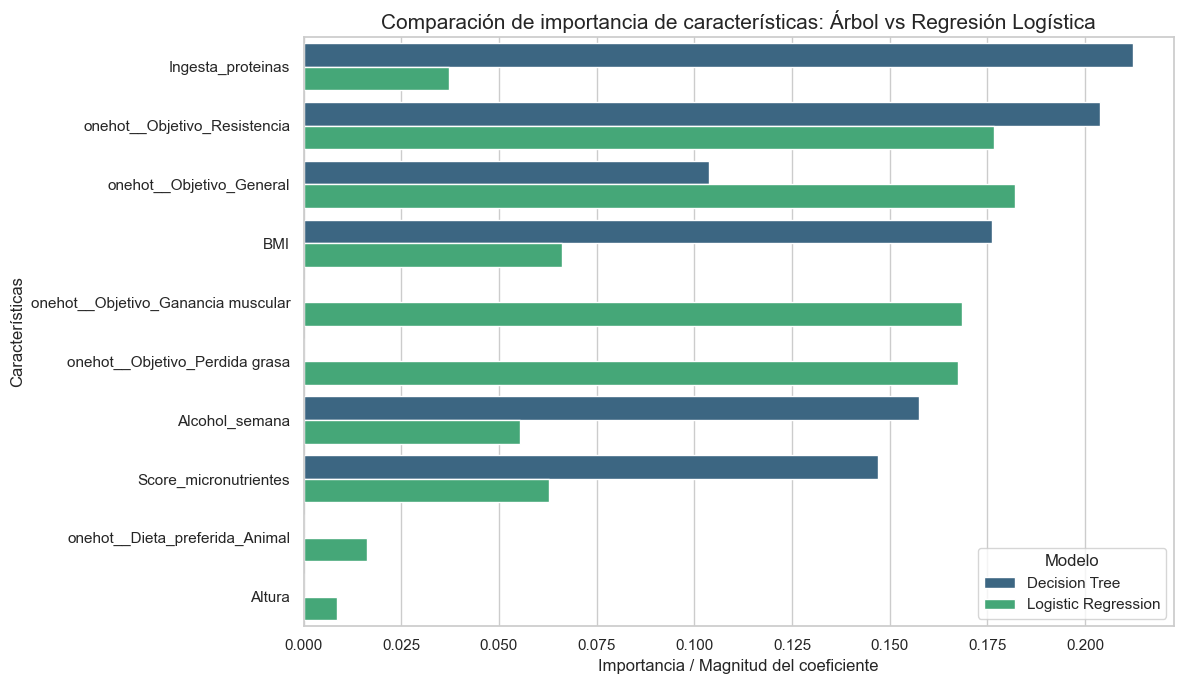

In [21]:
cat_names = list(grid_tree_nutricion.best_estimator_['preprocessor']
                 .transformers_[0][1].get_feature_names_out())
num_cols_final = [c for c in (numerical_cols + binary_cols) if c not in ['Alcohol', 'Fumador', 'Peso']]
all_feature_names_nut = cat_names + num_cols_final

importances_nut_dt = grid_tree_nutricion.best_estimator_['classifier'].feature_importances_
coefs_nut_lr = grid_nutricion.best_estimator_['classifier'].coef_

if coefs_nut_lr.ndim == 1:
    log_importance = pd.Series(np.abs(coefs_nut_lr), index=all_feature_names_nut)
else:
    log_importance = pd.Series(np.abs(coefs_nut_lr).mean(axis=0), index=all_feature_names_nut)

importancia_nutricion = pd.Series(importances_nut_dt, index=all_feature_names_nut).sort_values(ascending=False)
importancia_logistica = log_importance.sort_values(ascending=False)
importancia_logistica = importancia_logistica/importancia_logistica.sum()

print('Top 10 Decision Tree:')
print(importancia_nutricion.head(10))
print('\nTop 10 Logistic Regression (coef abs mean):')
print(importancia_logistica.head(10))

top_features = pd.DataFrame({
    'Decision Tree': importancia_nutricion,
    'Logistic Regression': importancia_logistica
}).fillna(0)
top_features = top_features.assign(Max=top_features.max(axis=1)).sort_values('Max', ascending=False).head(10).drop(columns='Max')
top_features = top_features.reset_index().melt(id_vars='index', var_name='Modelo', value_name='Importancia')

plt.figure(figsize=(12, 7))
sns.set_theme(style='whitegrid')
sns.barplot(data=top_features, x='Importancia', y='index', hue='Modelo', palette='viridis')

plt.title('Comparación de importancia de características: Árbol vs Regresión Logística', fontsize=15)
plt.xlabel('Importancia / Magnitud del coeficiente', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

El análisis de las variables de mayor peso para el modelo de nutrición muestra una distribución más equilibrada entre factores metabólicos y de hábitos, ignorando variables demográficas y condiciones de salud. Se notan diferencias más amplias para los dos tipos de modelos entrenados, ya que la regresión logística tiene bastante en cuenta todos los objetivos existentes en los datos, mientras que el árbol de decisión ignora los objetivos de pérdida de grasa y ganancia muscular. En general, las características más importantes son:

1. **Ingesta de Proteínas y Objetivo** 
2. **BMI y Alcohol a la semana**
3. **Score de Micronutrientes** 

El desempeño casi perfecto para el árbol de decisión confirma que la recomendación nutricional sigue un algoritmo de asignación determinístico basado en métricas de rendimiento y biometría. A su vez se observa que para esta clasificación, ambos modelos toman estrategias distintas para decidir la clase de plan nutricional, sin embargo el desempeño de regresión logística es menor pero con métricas buenas.

## Comparativa de Modelos
La siguiente tabla resume el rendimiento de los mejores modelos encontrados mediante búsqueda de hiperparámetros.

In [22]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    return [round(p, 4), round(r, 4), round(f1, 4)]

# Crear la estructura de la tabla
data = {
    'Objetivo': ['Entrenamiento', 'Entrenamiento', 'Nutrición', 'Nutrición'],
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Regresión Logística', 'Árbol de Decisión'],
    'Precisión (Macro)': [
        get_metrics(grid_entrenamiento, X_test, y_entrenamiento_test)[0],
        get_metrics(grid_tree_entrenamiento, X_test, y_entrenamiento_test)[0],
        get_metrics(grid_nutricion, X_test, y_nutricion_test)[0],
        get_metrics(grid_tree_nutricion, X_test, y_nutricion_test)[0]
    ],
    'Recall (Macro)': [
        get_metrics(grid_entrenamiento, X_test, y_entrenamiento_test)[1],
        get_metrics(grid_tree_entrenamiento, X_test, y_entrenamiento_test)[1],
        get_metrics(grid_nutricion, X_test, y_nutricion_test)[1],
        get_metrics(grid_tree_nutricion, X_test, y_nutricion_test)[1]
    ],
    'F1-Score (Macro)': [
        get_metrics(grid_entrenamiento, X_test, y_entrenamiento_test)[2],
        get_metrics(grid_tree_entrenamiento, X_test, y_entrenamiento_test)[2],
        get_metrics(grid_nutricion, X_test, y_nutricion_test)[2],
        get_metrics(grid_tree_nutricion, X_test, y_nutricion_test)[2]
    ]
}

df_comparativo = pd.DataFrame(data)

df_comparativo

,Objetivo,Modelo,Precisión (Macro),Recall (Macro),F1-Score (Macro)
0,Entrenamiento,Regresión Logística,0.6827,0.6542,0.6566
1,Entrenamiento,Árbol de Decisión,1.0000,1.0000,1.0000
2,Nutrición,Regresión Logística,0.7423,0.6983,0.7148
3,Nutrición,Árbol de Decisión,0.9979,0.9974,0.9976


* En ambos objetivos (Entrenamiento y Nutrición), el **Árbol de Decisión** superó significativamente a la **Regresión Logística**. Esto confirma que las reglas de negocio del gimnasio no son lineales y dependen de condiciones específicas de los clientes.
* **Estabilidad del Recall:** Mientras que la Regresión Logística presentaba un recall bajo en ciertas clases (como el Plan Bajo), el Árbol de Decisión logra capturar casi la totalidad de los casos en todas las categorías.
* **Análisis de Precisión:** La precisión perfecta del árbol en Entrenamiento (1.0) frente al 0.68 de la logística sugiere que el modelo basado en reglas es el más apto para replicar el protocolo de SmartAlpes, siempre que se vigile el riesgo de sobreajuste.

## Selección del mejor modelo
Como mejor modelo tomamos el modelo con mejores parámetros observados usando árboles de decisión, tanto para planes de entrenamiento, como para planes nutricionales.

In [23]:
mejor_modelo_entrenamiento = grid_tree_entrenamiento.best_estimator_
mejor_modelo_nutricion = grid_tree_nutricion.best_estimator_

## Análisis de resultados
- ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?
    
    Para planes de entrenamiento las variables que más tienen incidencia en la recomendación del plan, son: el nivel de actividad, el nivel de experiencia, si el objetivo es la ganancia muscular y el BMI. 
    Mientras tanto para los planes nutricionales existe una diferencia entre el modelo usado para la clasificación, para el modelo de regresión logística todos los objetivos son importantes, el árbol de decisión solo considera relevantes los objetivos de resistencia y general. Ambos consideran el score de micronutrientes, el BMI, la ingesta de proteínas y el consumo de alcohol como variables importantes para el sistema de recomendación.
- ¿Existen variables que podrían ser redundantes o poco informativas?

    Para ambos modelos, las variables demográficas, como edad, altura, género, entre otros parece ser poco informativa para elegir planes de entrenamiento y nutrición.

- ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?

    El modelo basado en regresión logística logra una recomendación moderadamente acertada para la mayoría de los datos, sin embargo el modelo basado en árbol de decisión logra un desempeño casi perfecto en los datos, que puede explicarse por reglas estrictas para la recomendación en los datos de entrenamiento, por lo que estas reglas pueden reproducirse casi exactamente usando un árbol de decisión.

- A partir de alguno de los modelos creados con árboles de decisión, describa en términos de reglas, las características que cumplen las variables involucradas en la recomendación que se da. Incluya además, la utilidad y la limitación que tienen este estilo de reglas en modelos de árboles de decisión principalmente en el proceso de explicabilidad del modelo.

    Una regla en nuestro modelo sería: **"Si el objetivo es ganar músculo, el nivel de experiencia es alto y el tiempo disponible es de más de 60 min, entonces asignar Plan Alto".** La utilidad de esto es que es muy fácil de explicar a un cliente o a un entrenador por qué salió ese resultado, es decir, es "explicable". La limitación es que estas reglas son muy rígidas; si un cliente nuevo se sale un poquito de lo normal, el árbol puede no saber qué hacer o dar una respuesta forzada porque no tiene flexibilidad, solo sigue el camino de la regla.

- ¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?

    Se podria poner como un cuestionario de bienvenida en la plataforma. El usuario llena sus datos (BMI, metas, hábitos) y el modelo le asignaria su plan de nutrición y entrenamiento automáticamente. También serviria para que los entrenadores humanos tengan una base sugerida y no empiecen de cero con cada cliente.

- ¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?

    La mayor limitación seria que el sistema no tiene "ojo humano". Por ejemplo, el modelo no sabe si el usuario tiene una molestia física que no reportó o si su técnica al hacer ejercicio es mala. Confiar al 100% en un algoritmo puede causar lesiones si el plan es muy pesado o frustración si es muy liviano, ya que el modelo no siente empatía ni entiende el contexto emocional del usuario.

- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

    Puede haber un sesgo de representación ya que si la mayoría de los datos son de gente joven o de cierto tipo de cuerpo, el modelo no sabrá qué recomendarle a una persona mayor. También podria haber un sesgo en la recolección, ya que los datos de "consumo de alcohol" o "proteína" los pone el usuario y la gente suele mentir o equivocarse en esas encuestas, lo que hace que el modelo aprenda de datos que no son 100% reales.


## Generación del archivo de respuesta
Inicialmente cargamos los datos de evaluación

In [24]:
X_eval = pd.read_csv('data/Datos test Lab3.csv', sep=';')
X_eval = X_eval.drop(columns=['Plan_entrenamiento', 'Plan_nutricion'])
X_eval.head()

,Edad,Genero,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0,0,0.0,0,0.0,0.21,169.0,8468,2.57
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0,0,0.0,0,0.0,0.58,52.4,11967,3.73
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0,0,0.0,0,0.0,0.37,189.5,15950,3.06
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,...,1,0,0,0.0,0,0.0,0.57,185.7,9384,2.18
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,...,1,0,0,0.0,1,23.7,0.21,182.1,10070,3.32


Realizamos la predicciones usando los mejores modelos

In [25]:
y_entrenamiento_eval = mejor_modelo_entrenamiento.predict(X_eval)
y_nutricion_eval = mejor_modelo_nutricion.predict(X_eval)
X_eval['Plan_entrenamiento'] = y_entrenamiento_eval
X_eval['Plan_nutricion'] = y_nutricion_eval
X_eval.sample(5)

,Edad,Genero,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutricion
272,49,Femenino,105.8,1.54,44.61,Perdida grasa,Ninguno,Alto,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.84,59.3,16991,1.43,Medio,Balanceado
7,66,Masculino,92.6,1.93,24.86,Ganancia muscular,Diabetes,Alto,Principiante,Vegetariano,...,1,6.6,0,0.0,0.12,70.8,5319,3.39,Medio,Balanceado
164,51,Masculino,86.4,2.01,21.39,Perdida grasa,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.10,71.1,10500,4.01,Alto,Balanceado
8,25,Masculino,76.4,1.84,22.57,Resistencia,Ninguno,Bajo,Principiante,Vegetariano,...,0,0.0,0,0.0,0.60,59.8,14582,3.39,Ninguno,Sin plan
6,55,Masculino,75.0,1.71,25.65,Ganancia muscular,Hipertension,Bajo,Intermedio,No-Vegetariano,...,0,0.0,0,0.0,0.34,141.3,5710,2.60,Bajo,Balanceado


Guardamos las predicciones en el archivo de respuestas

In [26]:
X_eval.to_csv('data/Datos test Lab3.csv', sep=';', index=False)

## Uso de IA Generativa

Para el desarrollo de este laboratorio se utilizaron dos herramientas principales: **GPT-4o (OpenAI)** para el apoyo en la comprensión del contexto del proyecto y **Claude 3.5 Sonnet (Anthropic)** como asistente en el ensamblaje de la lógica técnica y la búsqueda de hiperparámetros.

El uso de estas herramientas fue fundamental en las siguientes etapas:

**Entendimiento del problema:** La IA fue útil para desglosar los requerimientos del laboratorio y entender el contexto del sistema de recomendación de SmartAlpes. Un ejemplo del tipo de interacción realizada fue el siguiente:
    
* *Prompt de ejemplo:* "Actúa como un experto en Ciencia de Datos. Explícame de forma sencilla cómo un sistema de clasificación basado en árboles de decisión puede ayudar a un gimnasio a recomendar planes de entrenamiento y nutrición, y qué importancia tiene el balanceo de clases en este problema".

**Estructuración y optimización:** Se utilizaron funciones cocreadas con la IA para agilizar el ensamblaje de los pipelines y la configuración de las mallas de búsqueda (`param_grid`) para los modelos de Regresión Logística y Árboles de Decisión. Todas estas funciones fueron revisadas y validadas por los estudiantes para asegurar que cumplían con los criterios técnicos del laboratorio.

**Visualización y reporte:** Se empleó apoyo para la generación de gráficas de importancia de variables y la construcción de la tabla comparativa de métricas (Precision, Recall, F1-Score).

Es importante resaltar que, aunque la IA facilitó la implementación técnica, el análisis crítico de los resultados, especialmente la identificación del sobreajuste (overfitting) en los árboles de decisión y la interpretación de la importancia de las variables, fue realizado por los estudiantes. 

La lógica del preprocesamiento, como el uso de transformadores personalizados para el tratamiento de las horas de sueño y la eliminación de variables redundantes, es autoría de los estudiantes basada en el análisis previo de los datos.